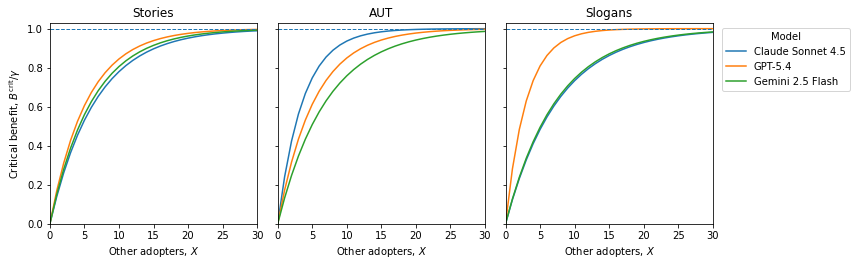

Saved: analysis_outputs/figures/main_critical_benefit_curves_by_task_model.pdf


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TABLE_DIR = Path("analysis_outputs/tables")
FIG_DIR = Path("analysis_outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

main_results = pd.read_csv(TABLE_DIR / "main_results_semantic_crowding_table.csv")

# Expected columns: model, task, Delta
x_grid = np.arange(0, 31)

task_order = ["story", "aut", "slogan"]
task_title = {
    "story": "Stories",
    "aut": "AUT",
    "slogan": "Slogans",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, task in zip(axes, task_order):
    sub = main_results[main_results["task"] == task].copy()

    for _, row in sub.iterrows():
        delta = float(row["Delta"])
        y = 1 - np.exp(-x_grid * delta)
        ax.plot(x_grid, y, label=row["model"])

    ax.set_title(task_title[task])
    ax.set_xlabel("Other adopters, $X$")
    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_ylim(0, 1.03)
    ax.set_xlim(0, x_grid.max())

axes[0].set_ylabel(r"Critical benefit, $B^{\mathrm{crit}}/\gamma$")
axes[-1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
out_path = FIG_DIR / "main_critical_benefit_curves_by_task_model.pdf"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)